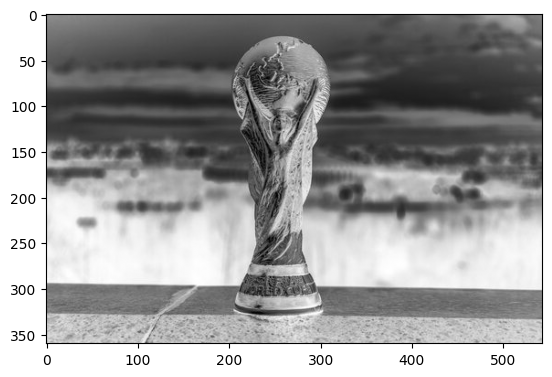

In [1]:
#Bai lab 2 
#1. Viết chương trình xử lý điểm ảnh
#1.1 Biến đổi cường độ ảnh
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt

# Mở ảnh mức xám
img = Image.open('cup.jpg').convert('L')

# Chuyển ảnh sang mảng NumPy
im_1 = np.asarray(img)

# Đảo ảnh: pixel mới = 255 - pixel cũ
im_2 = 255 - im_1

# Chuyển mảng NumPy trở lại ảnh
new_img = Image.fromarray(im_2)

# Hiển thị ảnh gốc
img.show()

# Hiển thị ảnh đảo bằng matplotlib
plt.imshow(new_img, cmap='gray')
plt.show()


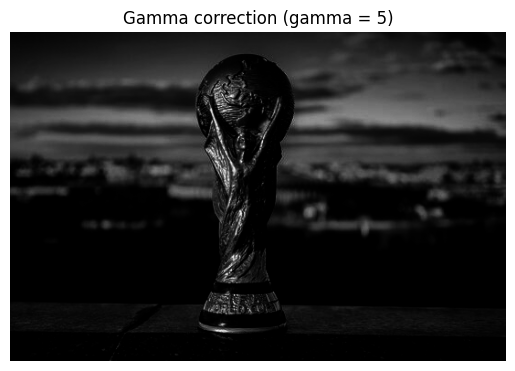

In [2]:
#1.2 ThaY đổi chất lượng ảnh với Power law
#DÙng để tăng chất lượng ảnh
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# Mở ảnh grayscale
img = Image.open('cup.jpg').convert('L')

# Chuyển ảnh sang mảng NumPy
im_1 = np.asarray(img)

# Giá trị gamma cần chỉnh: thử 0.5, 1.0, 2.2, 5.0, v.v.
gamma = 5   # ← Bạn thay đổi giá trị tại đây để xem ảnh khác nhau

# Bước 1: Chuyển kiểu int sang float
b1 = im_1.astype(float)

# Bước 2: Tìm giá trị lớn nhất của ảnh để chuẩn hóa
b2 = np.max(b1)

# Bước 3: Chuẩn hóa ảnh về [0,1]
b3 = b1 / b2

# Bước 4: Nhân gamma vào log của ảnh
b2_log = np.log(b3 + 1e-8) * gamma  # thêm epsilon nhỏ để tránh log(0)

# Bước 5: Áp dụng mũ để phục hồi ảnh sau khi log
c = np.exp(b2_log) * 255.0

# Bước 6: Chuyển về số nguyên 8 bit
c1 = c.astype(np.uint8)

# Tạo ảnh mới từ mảng đã hiệu chỉnh
d = Image.fromarray(c1)
d.save(f'cup_gamma_{gamma}.png')
# Hiển thị ảnh gốc
img.show()

# Hiển thị ảnh đã chỉnh gamma
plt.imshow(d, cmap='gray')
plt.title(f"Gamma correction (gamma = {gamma})")
plt.axis('off')
plt.show()


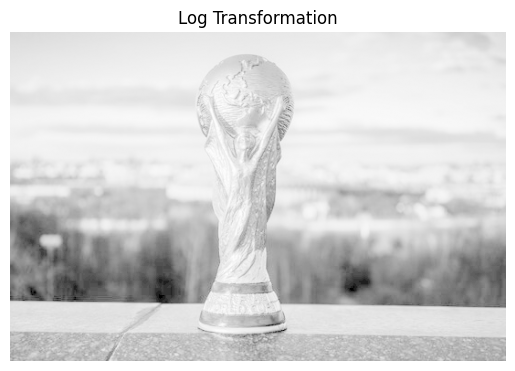

In [3]:
#1.3 Thay đổi cường độ điểm ảnh với Log Transformation
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# Mở ảnh grayscale
img = Image.open('cup.jpg').convert('L')

# Chuyển ảnh sang mảng NumPy
im_1 = np.asarray(img)

# Chuyển kiểu int sang float để xử lý toán học
b1 = im_1.astype(float)

# Tìm giá trị lớn nhất trong ảnh để chuẩn hóa
b2 = np.max(b1)

# Biến đổi logarit: 
# Áp dụng công thức chuẩn hóa log: c = (255 * log(1 + I)) / log(1 + max)
c = (255.0 * np.log(1 + b1)) / np.log(1 + b2)

# Chuyển về kiểu số nguyên 8-bit
c1 = c.astype(np.uint8)

# Tạo ảnh từ mảng đã biến đổi
d = Image.fromarray(c1)

# Hiển thị ảnh gốc
img.show()

# Hiển thị ảnh sau log transformation
plt.imshow(d, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()


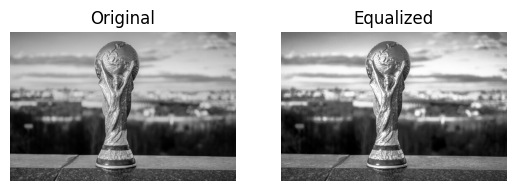

In [4]:
#1.4 Histogram equalization
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# Mở ảnh mức xám
img = Image.open('cup.jpg').convert('L')

# Chuyển sang mảng NumPy
im1 = np.asarray(img)

# Chuyển về mảng 1 chiều để xử lý histogram
b1 = im1.flatten()

# Tính histogram và CDF (cumulative distribution function)
hist, bins = np.histogram(im1, 256, [0, 255])
cdf = hist.cumsum()

# Bỏ qua các giá trị không thay đổi (các giá trị cdf = 0)
cdf_m = np.ma.masked_equal(cdf, 0)

# Chuẩn hóa CDF để đưa vào khoảng 0–255
num_cdf = (cdf_m - cdf_m.min()) * 255
den_cdf = cdf_m.max() - cdf_m.min()
cdf_m = num_cdf / den_cdf

# Thay thế các giá trị đã che bằng 0, rồi ép kiểu uint8
cdf = np.ma.filled(cdf_m, 0).astype('uint8')

# Gán các giá trị histogram cân bằng vào ảnh
im2 = cdf[b1]

# Đưa ảnh về dạng 2D
im3 = im2.reshape(im1.shape)

# Chuyển thành ảnh để hiển thị
img2 = Image.fromarray(im3)

# Hiển thị ảnh gốc và ảnh sau khi histogram equalization
img.show()
img2.show()

# Dùng matplotlib hiển thị lại
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(im1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Equalized")
plt.imshow(im3, cmap='gray')
plt.axis('off')

plt.show()


Max pixel value: 255
Min pixel value: 0


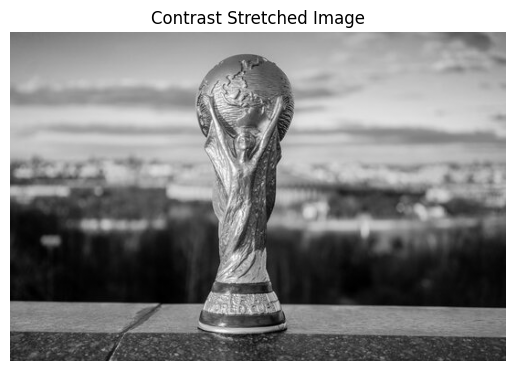

In [5]:
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt

# Mở ảnh grayscale
img = Image.open('cup.jpg').convert('L')

# Chuyển ảnh thành mảng numpy
im1 = np.asarray(img)

# Tìm giá trị pixel lớn nhất và nhỏ nhất
b = im1.max()
a = im1.min()
print("Max pixel value:", b)
print("Min pixel value:", a)

# Chuyển sang kiểu float để xử lý
c = im1.astype(float)

# Thực hiện phép kéo giãn tương phản (contrast stretching)
im2 = 255 * (c - a) / (b - a)

# Chuyển lại về ảnh từ mảng numpy
im3 = Image.fromarray(im2.astype(np.uint8))

# Hiển thị ảnh gốc và ảnh đã xử lý
img.show()         # Ảnh gốc
im3.show()         # Ảnh sau contrast stretching

# Hoặc hiển thị bằng matplotlib
plt.imshow(im3, cmap='gray')
plt.title("Contrast Stretched Image")
plt.axis('off')
plt.show()


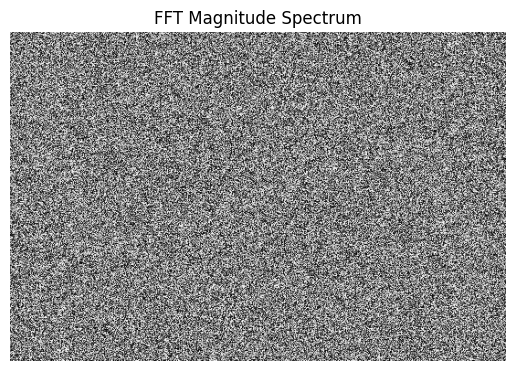

In [6]:
#1.6 Biến đổi Fourier
#1.6.1 Biến đổi ảnh với Fast Fourier
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.fftpack

# Mở ảnh grayscale
img = Image.open('cup.jpg').convert('L')

# Chuyển ảnh thành mảng numpy
im1 = np.asarray(img)

# Thực hiện biến đổi Fourier nhanh (FFT)
c = abs(scipy.fftpack.fft2(im1))

# Dời ảnh phổ về tâm (centered FFT)
c = scipy.fftpack.fftshift(c)

# Chuyển sang kiểu float để hiển thị
d = c.astype(float)

# Tạo ảnh từ mảng dữ liệu
im3 = Image.fromarray(d.astype(np.uint8))  # phải ép kiểu uint8 để hiển thị được

# Hiển thị ảnh gốc và ảnh sau biến đổi Fourier
img.show()        # Ảnh gốc
im3.show()        # Ảnh phổ tần số
plt.imshow(im3, cmap='gray')
plt.title("FFT Magnitude Spectrum")
plt.axis('off')
plt.show()


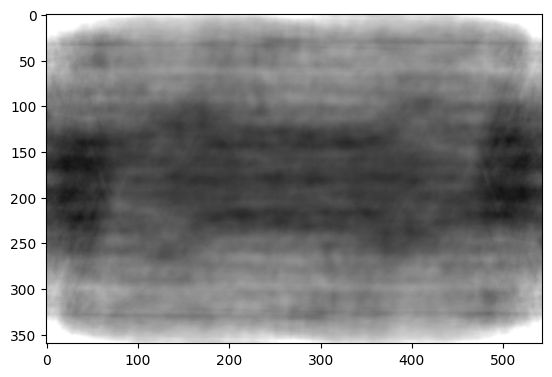

In [7]:
#1.6.2 Lọc ảnh trong miền tần suất
#Butterworth Lowpass Filter
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt

# open a grayscale image
img = Image.open('cup.jpg').convert('L')
# convert image 1 into an ndarray
im1 = np.asarray(img)

# performing FFT
c = abs(scipy.fftpack.fft2(im1))
# shifting the Fourier frequency image
d = scipy.fftpack.fftshift(c)

# initializing variables for convolution function
M = d.shape[0]
N = d.shape[1]
# H is defined and values in H are initialized to 1
H = np.ones((M, N))

center1 = M/2
center2 = N/2
d_0 = 30.0 # cut-off radius
t1 = 1 # the order of BLPF (Butterworth Lowpass Filter)
t2 = 2 * t1

# defining the convolution function for BLPF
for i in range(M):
    for j in range(N):
        r1 = (i - center1)**2 + (j - center2)**2
        # euclidean distance from origin is computed
        r = math.sqrt(r1)
        # using cut-off radius to eliminate high frequency
        if r > 0:
            H[i, j] = 1 / (1 + (r/d_0)**t1)

# H is converted from ndarray to image
H = H.astype(float)
im3 = Image.fromarray(H)

# performing the convolution
con = d * H

# computing the magnitude of the inverse FFT
e = abs(scipy.fftpack.ifft2(con))
# e is converted from ndarray to image
e = e.astype(float)
im3 = Image.fromarray(e)

img.show()
im3.show()
plt.imshow(im3)
plt.show()


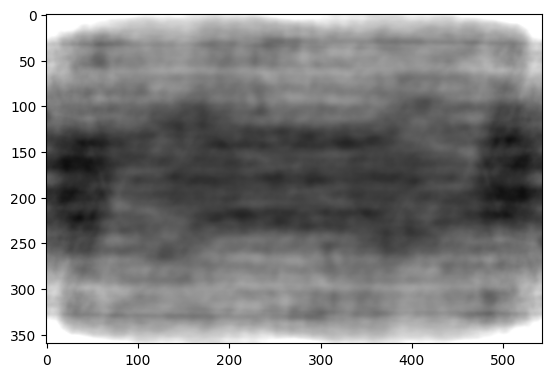

In [8]:
#Butterworth highpass Filter
from PIL import Image
import math
import scipy
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt

# open a grayscale image
img = Image.open('cup.jpg').convert('L')
# convert image 1 into an ndarray
#im1 = np.asarray(img)
#
# performing FFT
c = abs(scipy.fftpack.fft2(im1))
# shifting the Fourier frequency image
d = scipy.fftpack.fftshift(c)
# initializing variables for convolution function
M = d.shape[0]
N = d.shape[1]
# H is defined and values in H are initialized to 1
H = np.ones((M, N))

center1 = M/2
center2 = N/2
d_0 = 30.0 # cut-off radius
t1 = 1 # the order of BLPF (Butterworth Lowpass Filter)
t2 = 2 * t1

# defining the convolution function for BLPF
for i in range(M):
    for j in range(N):
        r1 = (i - center1)**2 + (j - center2)**2
        # euclidean distance from origin is computed
        r = math.sqrt(r1)
        # using the cut-off radius to eliminate high frequency
        if r > 0.0:
            H[i, j] = 1 / (1 + (r/d_0)**t2)

# H is converted from ndarray to image
H = H.astype(float)
im2 = Image.fromarray(H)

# performing the convolution
con = H * d

# computing the magnitude of the inverse FFT
e = abs(scipy.fftpack.ifft2(con))
# e is converted from ndarray to image
e = e.astype(float)
im3 = Image.fromarray(e)

img.show()
im3.show()
plt.imshow(im3)
plt.show()



Chọn một phương pháp biến đổi ảnh:
F - Biến đổi ảnh ngược
G - Biến đổi Gamma
L - Biến đổi Log
H - Cân bằng histogram
C - Thoát
Nhập lựa chọn của bạn: F


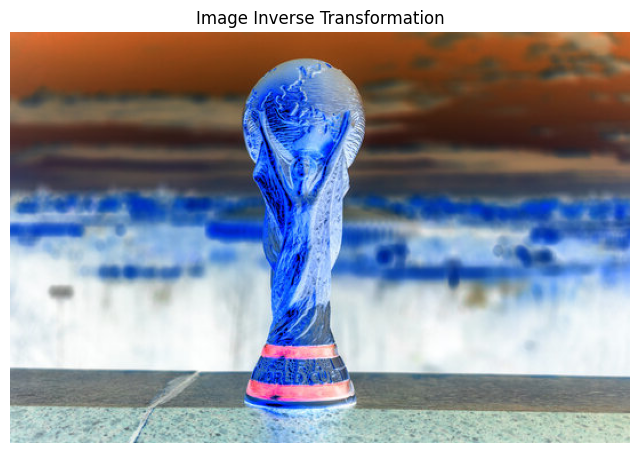


Chọn một phương pháp biến đổi ảnh:
F - Biến đổi ảnh ngược
G - Biến đổi Gamma
L - Biến đổi Log
H - Cân bằng histogram
C - Thoát
Nhập lựa chọn của bạn: G
Nhập giá trị Gamma (vd: 1.0, 2.2, 0.5): 2


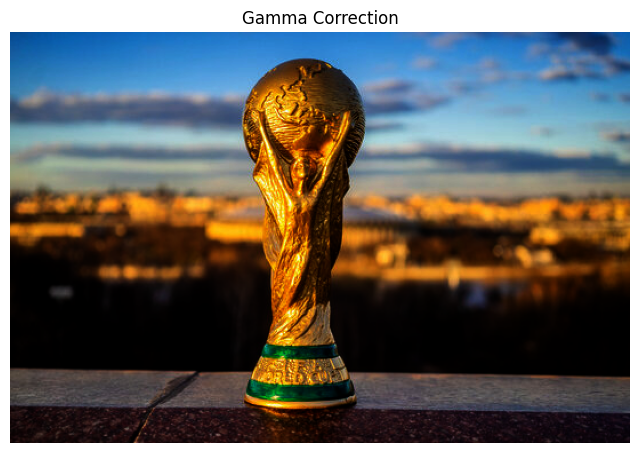


Chọn một phương pháp biến đổi ảnh:
F - Biến đổi ảnh ngược
G - Biến đổi Gamma
L - Biến đổi Log
H - Cân bằng histogram
C - Thoát
Nhập lựa chọn của bạn: L


/tmp/ipython-input-20-3999412298.py:18: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(image))
/tmp/ipython-input-20-3999412298.py:18: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(image))
/tmp/ipython-input-20-3999412298.py:19: RuntimeWarning: divide by zero encountered in log
  return np.array(c * (np.log(image + 1)), dtype=np.uint8)
/tmp/ipython-input-20-3999412298.py:19: RuntimeWarning: invalid value encountered in multiply
  return np.array(c * (np.log(image + 1)), dtype=np.uint8)
/tmp/ipython-input-20-3999412298.py:19: RuntimeWarning: invalid value encountered in cast
  return np.array(c * (np.log(image + 1)), dtype=np.uint8)


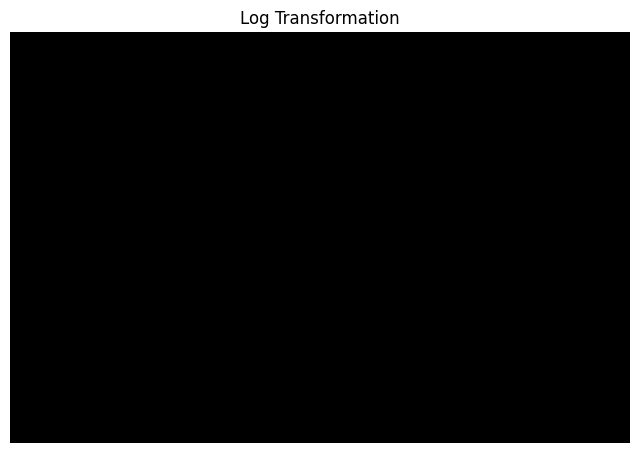


Chọn một phương pháp biến đổi ảnh:
F - Biến đổi ảnh ngược
G - Biến đổi Gamma
L - Biến đổi Log
H - Cân bằng histogram
C - Thoát
Nhập lựa chọn của bạn: H


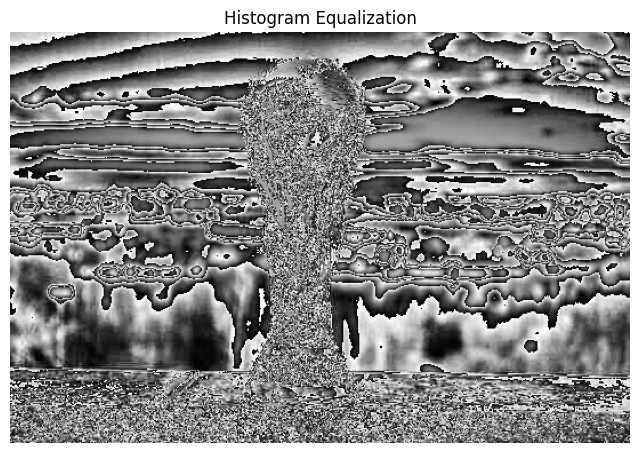


Chọn một phương pháp biến đổi ảnh:
F - Biến đổi ảnh ngược
G - Biến đổi Gamma
L - Biến đổi Log
H - Cân bằng histogram
C - Thoát
Nhập lựa chọn của bạn: C
Thoát chương trình.


In [20]:
#Bai LAB 2
#Bai tập
#Câu 1:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
from scipy import ndimage
import time  # Import thư viện time để thêm độ trễ

# Hàm để thực hiện biến đổi ảnh ngược (Image Inverse Transformation)
def inverse_transformation(image):
    return 255 - image

# Hàm để thực hiện biến đổi Gamma (Gamma Correction)
def gamma_correction(image, gamma=1.0):
    return np.array(255 * (image / 255) ** gamma, dtype=np.uint8)

# Hàm để thực hiện biến đổi Log (Log Transformation)
def log_transformation(image):
    c = 255 / np.log(1 + np.max(image))
    return np.array(c * (np.log(image + 1)), dtype=np.uint8)

# Hàm để thực hiện cân bằng histogram (Histogram Equalization)
def histogram_equalization(image):
    # Convert ảnh về grayscale nếu là ảnh màu
    if len(image.shape) == 3:
        image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])  # Chuyển sang ảnh grayscale
    # Cân bằng histogram
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()  # CDF: Cộng dồn các giá trị trong histogram
    cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Chuẩn hóa CDF
    image_equalized = np.interp(image.flatten(), bins[:-1], cdf_normalized)
    return image_equalized.reshape(image.shape).astype(np.uint8)

# Hàm hiển thị ảnh
def show_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hàm chính tạo menu và thực hiện biến đổi ảnh
def main(image_path):
    # Đọc ảnh từ file
    image = iio.imread(image_path)  # Đọc ảnh bằng imageio

    if image is None:
        print("Không thể mở ảnh!")
        return

    # Vòng lặp chính
    while True:
        print("\nChọn một phương pháp biến đổi ảnh:")
        print("F - Biến đổi ảnh ngược")
        print("G - Biến đổi Gamma")
        print("L - Biến đổi Log")
        print("H - Cân bằng histogram")
        print("C - Thoát")

        # Nhập lựa chọn từ người dùng
        choice = input("Nhập lựa chọn của bạn: ").upper()

        if choice == 'F':
            transformed_image = inverse_transformation(image)
            show_image(transformed_image, "Image Inverse Transformation")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == 'G':
            gamma = float(input("Nhập giá trị Gamma (vd: 1.0, 2.2, 0.5): "))
            transformed_image = gamma_correction(image, gamma)
            show_image(transformed_image, "Gamma Correction")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == 'L':
            transformed_image = log_transformation(image)
            show_image(transformed_image, "Log Transformation")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == 'H':
            transformed_image = histogram_equalization(image)
            show_image(transformed_image, "Histogram Equalization")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == 'C':
            print("Thoát chương trình.")
            break  # Thoát khỏi vòng lặp khi chọn "C"

        else:
            print("Lựa chọn không hợp lệ! Vui lòng thử lại.")

# Đọc và chạy chương trình với đường dẫn ảnh
image_path = 'cup.jpg'  # Thay bằng đường dẫn ảnh của bạn
main(image_path)



Chọn một phương pháp biến đổi ảnh:
1 - Biến đổi Fourier
2 - Bộ lọc Butterworth Lowpass
3 - Bộ lọc Butterworth Highpass
4 - Thoát
Nhập lựa chọn của bạn (1-4): 1


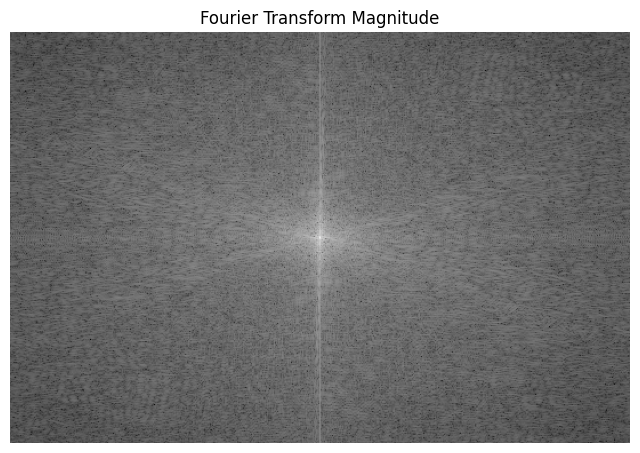


Chọn một phương pháp biến đổi ảnh:
1 - Biến đổi Fourier
2 - Bộ lọc Butterworth Lowpass
3 - Bộ lọc Butterworth Highpass
4 - Thoát
Nhập lựa chọn của bạn (1-4): 2
Nhập giá trị cắt tần số (cutoff): 0.5


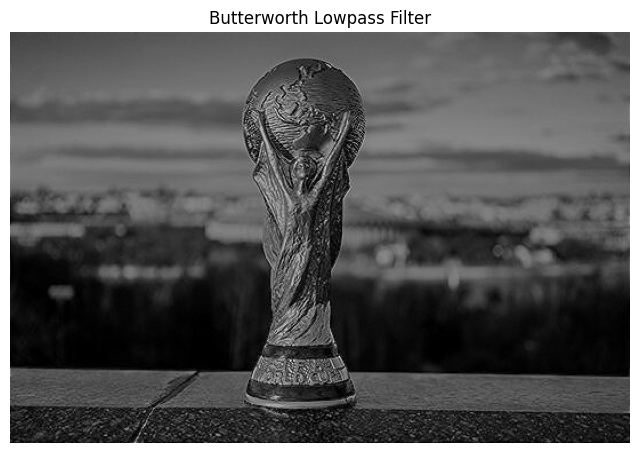


Chọn một phương pháp biến đổi ảnh:
1 - Biến đổi Fourier
2 - Bộ lọc Butterworth Lowpass
3 - Bộ lọc Butterworth Highpass
4 - Thoát
Nhập lựa chọn của bạn (1-4): 3
Nhập giá trị cắt tần số (cutoff): 0.5


/tmp/ipython-input-13-1575325758.py:51: RuntimeWarning: divide by zero encountered in divide
  H = 1 / (1 + (cutoff / D)**(2 * order))


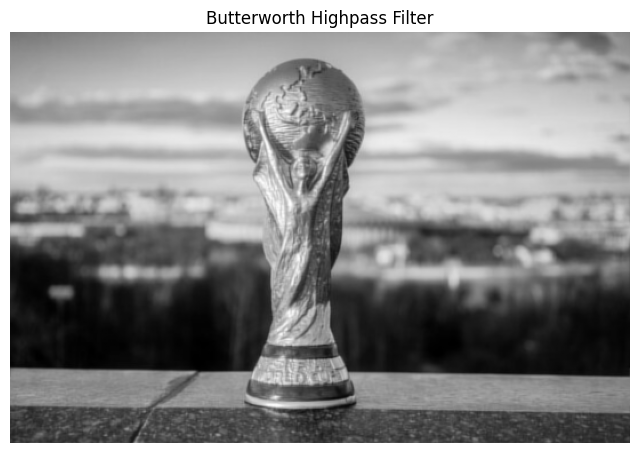


Chọn một phương pháp biến đổi ảnh:
1 - Biến đổi Fourier
2 - Bộ lọc Butterworth Lowpass
3 - Bộ lọc Butterworth Highpass
4 - Thoát
Nhập lựa chọn của bạn (1-4): 4
Thoát chương trình.


In [13]:
#Câu 2
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
from scipy import fftpack
import time  # Để sử dụng độ trễ giữa các lựa chọn

# Hàm biến đổi Fourier (Fast Fourier Transform)
def fourier_transform(image):
    # Chuy đổi ảnh thành không gian tần số bằng FFT
    f_transform = fftpack.fftshift(fftpack.fft2(image))  # Áp dụng FFT và dịch chuyển trung tâm
    magnitude = np.abs(f_transform)  # Lấy độ lớn của FFT
    phase = np.angle(f_transform)  # Lấy pha của FFT

    return magnitude, phase, f_transform

# Hàm bộ lọc Butterworth Lowpass
def butterworth_lowpass(image, cutoff, order=2):
    rows, cols = image.shape
    # Tạo các chỉ số tần số trong không gian
    u = np.fft.fftfreq(rows)[:, None] # Add None to create a column vector
    v = np.fft.fftfreq(cols)[None, :] # Add None to create a row vector
    U, V = np.meshgrid(u, v, indexing='ij') # Use ij indexing for consistent dimensions

    # Tính toán khoảng cách tần số
    D = np.sqrt(U**2 + V**2)

    # Bộ lọc Butterworth
    H = 1 / (1 + (D / cutoff)**(2 * order))

    # Áp dụng bộ lọc vào ảnh đã chuyển sang không gian tần số
    f_transform = fftpack.fftshift(fftpack.fft2(image))
    f_transform_filtered = f_transform * H

    # Chuyển ngược về không gian không gian ảnh
    image_filtered = np.abs(fftpack.ifft2(fftpack.ifftshift(f_transform_filtered)))

    return image_filtered

# Hàm bộ lọc Butterworth Highpass
def butterworth_highpass(image, cutoff, order=2):
    rows, cols = image.shape
    # Tạo các chỉ số tần số trong không gian
    u = np.fft.fftfreq(rows)[:, None] # Add None to create a column vector
    v = np.fft.fftfreq(cols)[None, :] # Add None to create a row vector
    U, V = np.meshgrid(u, v, indexing='ij') # Use ij indexing for consistent dimensions

    # Tính toán khoảng cách tần số
    D = np.sqrt(U**2 + V**2)

    # Bộ lọc Butterworth Highpass
    H = 1 / (1 + (cutoff / D)**(2 * order))

    # Áp dụng bộ lọc vào ảnh đã chuyển sang không gian tần số
    f_transform = fftpack.fftshift(fftpack.fft2(image))
    f_transform_filtered = f_transform * H

    # Chuyển ngược về không gian không gian ảnh
    image_filtered = np.abs(fftpack.ifft2(fftpack.ifftshift(f_transform_filtered)))

    return image_filtered

# Hàm hiển thị ảnh trong
def show_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hàm kiểm tra và chuyển đổi giá trị nhập vào thành số thực hợp lệ
def get_cutoff_value():
    while True:
        try:
            cutoff = input("Nhập giá trị cắt tần số (cutoff): ").strip()
            # Thử chuyển đổi đầu vào thành một số thực
            cutoff = float(cutoff)
            if 0.1 <= cutoff <= 0.5:  # Kiểm tra giá trị cutoff hợp lệ
                return cutoff
            else:
                print("Giá trị cutoff phải nằm trong khoảng từ 0.1 đến 0.5.")
        except ValueError:
            print("Giá trị cắt tần số không hợp lệ. Vui lòng nhập một số thực hợp lệ.")

# Hàm chính tạo menu và thực hiện biến đổi ảnh
def main(image_path):
    # Đọc ảnh từ file
    image = iio.imread(image_path)  # Đọc ảnh bằng imageio

    if image is None:
        print("Không thể mở ảnh!")
        return

    # Nếu ảnh là ảnh màu, chuyển sang grayscale
    if len(image.shape) == 3:
        image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])  # Chuyển sang ảnh grayscale

    # Vòng lặp chính
    while True:
        print("\nChọn một phương pháp biến đổi ảnh:")
        print("1 - Biến đổi Fourier")
        print("2 - Bộ lọc Butterworth Lowpass")
        print("3 - Bộ lọc Butterworth Highpass")
        print("4 - Thoát")

        # Nhập lựa chọn từ người dùng
        choice = input("Nhập lựa chọn của bạn (1-4): ").strip()

        if choice == '1':
            magnitude, phase, f_transform = fourier_transform(image)
            show_image(np.log(1 + magnitude), "Fourier Transform Magnitude")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == '2':
            cutoff = get_cutoff_value()  # Nhận giá trị cutoff hợp lệ
            filtered_image = butterworth_lowpass(image, cutoff)
            show_image(filtered_image, "Butterworth Lowpass Filter")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == '3':
            cutoff = get_cutoff_value()  # Nhận giá trị cutoff hợp lệ
            filtered_image = butterworth_highpass(image, cutoff)
            show_image(filtered_image, "Butterworth Highpass Filter")
            time.sleep(2)  # Thêm độ trễ 2 giây trước khi yêu cầu nhập lại

        elif choice == '4':
            print("Thoát chương trình.")
            break  # Thoát khỏi vòng lặp khi chọn "4"

        else:
            print("Lựa chọn không hợp lệ! Vui lòng thử lại.")

# Đọc và chạy chương trình với đường dẫn ảnh
image_path = 'cup.jpg'  # Thay bằng đường dẫn ảnh của bạn
main(image_path)

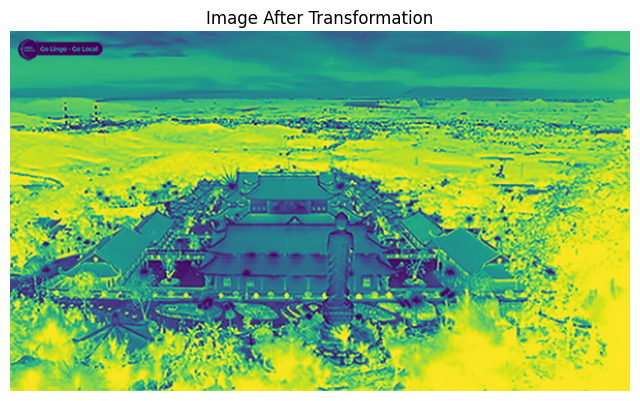

In [16]:
#Câu 3
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
from scipy import ndimage
import random
import time
import cv2

# Hàm để thực hiện biến đổi ảnh ngược (Image Inverse Transformation)
def inverse_transformation(image):
    return 255 - image

# Hàm để thực hiện biến đổi Gamma (Gamma Correction)
def gamma_correction(image, gamma=1.0):
    invGamma = 1.0 / gamma
    lookup_table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)], dtype='uint8')
    return cv2.LUT(image, lookup_table)

# Hàm để thực hiện biến đổi Log (Log Transformation)
def log_transformation(image):
    c = 255 / np.log(1 + np.max(image))
    return np.array(c * (np.log(image + 1)), dtype=np.uint8)

# Hàm để thực hiện cân bằng histogram (Histogram Equalization)
def histogram_equalization(image):
    if len(image.shape) == 2:  # Grayscale image
        return cv2.equalizeHist(image)
    else:
        # Đối với ảnh màu, chia thành các kênh màu và cân bằng histogram cho từng kênh
        img_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
        img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
        return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

# Hàm thay đổi tự màu RGB của ảnh (ngẫu nhiên làm sáng/tối các kênh)
def change_rgb(image):
    # Thay đổi ngẫu nhiên một kênh màu
    r, g, b = cv2.split(image)  # Tách các kênh R, G, B
    if random.choice([True, False]):
        r = cv2.add(r, 50)  # Làm sáng kênh đỏ (tăng độ sáng)
    else:
        g = cv2.subtract(g, 50)  # Làm tối kênh xanh lá (giảm độ sáng)
    return cv2.merge([r, g, b])

# Hàm thực hiện Min Filter (kích thước kernel nhỏ)
def min_filter(image, size=3):
    return ndimage.minimum_filter(image, size=size)

# Hàm thực hiện Max Filter (kích thước kernel nhỏ)
def max_filter(image, size=3):
    return ndimage.maximum_filter(image, size=size)

# Hàm hiển thị ảnh trong Jupyter Notebook
def show_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hàm chính tạo menu và thực hiện biến đổi ảnh
def main(image_path):
    # Đọc ảnh từ file
    image = iio.imread(image_path)  # Đọc ảnh bằng imageio

    if image is None:
        print("Không thể mở ảnh!")
        return

    # Nếu ảnh là ảnh màu, chuyển sang grayscale
    if len(image.shape) == 3:
        image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])  # Chuyển sang ảnh grayscale

    # Thay đổi tự màu RGB của ảnh
    # image = change_rgb(image) # Removed this line

    # Ngẫu nhiên chọn một phép biến đổi ảnh trong Câu 1
    transformations = [inverse_transformation, gamma_correction, log_transformation, histogram_equalization]
    selected_transformation = random.choice(transformations)

    # Nếu chọn Butterworth Lowpass, áp dụng Min Filter
    if selected_transformation == butterworth_lowpass:
        image = min_filter(image, size=3)  # Áp dụng Min Filter nếu chọn Lowpass

    # Nếu chọn Butterworth Highpass, áp dụng Max Filter
    if selected_transformation == butterworth_highpass:
        image = max_filter(image, size=3)  # Áp dụng Max Filter nếu chọn Highpass

    # Áp dụng phép biến đổi ảnh ngẫu nhiên
    image = selected_transformation(image)

    # Hiển thị ảnh đã biến đổi
    show_image(image, title="Image After Transformation")

# Đọc và chạy chương trình với đường dẫn ảnh
image_path = 'pagoda.jpg'  # Thay bằng đường dẫn ảnh của bạn
main(image_path)

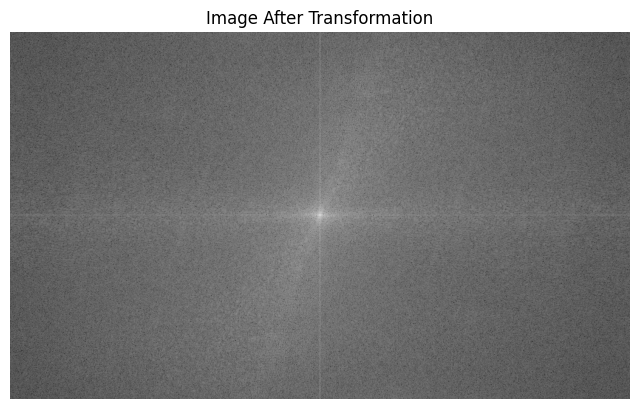

In [18]:
#Câu 4
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
from scipy import fftpack
import scipy.ndimage as ndimage
import random
import time
import cv2  # Thêm thư viện OpenCV để thao tác với ảnh

# Hàm biến đổi Fourier (Fast Fourier Transform)
def fourier_transform(image):
    f_transform = fftpack.fftshift(fftpack.fft2(image))  # Áp dụng FFT và dịch chuyển trung tâm
    magnitude = np.abs(f_transform)  # Lấy độ lớn của FFT
    return np.log(1 + magnitude)  # Trả về độ lớn (log scale để dễ nhìn hơn)

# Hàm bộ lọc Butterworth Lowpass
def butterworth_lowpass(image, cutoff, order=2):
    rows, cols = image.shape
    u = np.fft.fftfreq(rows)
    v = np.fft.fftfreq(cols)
    U, V = np.meshgrid(u, v)

    D = np.sqrt(U**2 + V**2)

    # Bộ lọc Butterworth Lowpass
    H = 1 / (1 + (D / cutoff)**(2 * order))

    # Áp dụng bộ lọc vào ảnh đã chuyển sang không gian tần số
    f_transform = fftpack.fftshift(fftpack.fft2(image))
    f_transform_filtered = f_transform * H

    # Chuyển ngược về không gian không gian ảnh
    image_filtered = np.abs(fftpack.ifft2(fftpack.ifftshift(f_transform_filtered)))

    return image_filtered

# Hàm bộ lọc Butterworth Highpass
def butterworth_highpass(image, cutoff, order=2):
    rows, cols = image.shape
    u = np.fft.fftfreq(rows)
    v = np.fft.fftfreq(cols)
    U, V = np.meshgrid(u, v)

    D = np.sqrt(U**2 + V**2)

    # Bộ lọc Butterworth Highpass
    H = 1 / (1 + (cutoff / D)**(2 * order))

    # Áp dụng bộ lọc vào ảnh đã chuyển sang không gian tần số
    f_transform = fftpack.fftshift(fftpack.fft2(image))
    f_transform_filtered = f_transform * H

    # Chuyển ngược về không gian không gian ảnh
    image_filtered = np.abs(fftpack.ifft2(fftpack.ifftshift(f_transform_filtered)))

    return image_filtered

# Hàm thay đổi tự màu RGB của ảnh (ngẫu nhiên làm sáng/tối các kênh)
def change_rgb(image):
    # Thay đổi ngẫu nhiên một kênh màu
    r, g, b = cv2.split(image)  # Tách các kênh R, G, B
    if random.choice([True, False]):
        r = cv2.add(r, 50)  # Làm sáng kênh đỏ (tăng độ sáng)
    else:
        g = cv2.subtract(g, 50)  # Làm tối kênh xanh lá (giảm độ sáng)
    return cv2.merge([r, g, b])

# Hàm thực hiện Min Filter (kích thước kernel nhỏ)
def min_filter(image, size=3):
    return ndimage.minimum_filter(image, size=size)

# Hàm thực hiện Max Filter (kích thước kernel nhỏ)
def max_filter(image, size=3):
    return ndimage.maximum_filter(image, size=size)

# Hàm hiển thị ảnh trong Jupyter Notebook
def show_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hàm chính tạo menu và thực hiện biến đổi ảnh
def main(image_path):
    # Đọc ảnh từ file
    image = iio.imread(image_path)  # Đọc ảnh bằng imageio

    if image is None:
        print("Không thể mở ảnh!")
        return

    # Nếu ảnh là ảnh màu, chuyển sang grayscale
    if len(image.shape) == 3:
        image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])  # Chuyển sang ảnh grayscale

    # Thay đổi tự màu RGB của ảnh
    # image = change_rgb(image) # Removed this line

    # Ngẫu nhiên chọn một phép biến đổi ảnh trong Câu 2
    transformations = [fourier_transform, butterworth_lowpass, butterworth_highpass]
    selected_transformation = random.choice(transformations)

    # Nếu chọn Butterworth Lowpass, áp dụng Min Filter
    if selected_transformation == butterworth_lowpass:
        cutoff = random.uniform(0.1, 0.5)
        image = min_filter(image, size=3)  # Áp dụng Min Filter nếu chọn Lowpass

    # Nếu chọn Butterworth Highpass, áp dụng Max Filter
    if selected_transformation == butterworth_highpass:
        cutoff = random.uniform(0.1, 0.5)
        image = max_filter(image, size=3)  # Áp dụng Max Filter nếu chọn Highpass

    # Áp dụng phép biến đổi ảnh ngẫu nhiên (Fourier hoặc Butterworth Filter)
    if selected_transformation == fourier_transform:
        image = selected_transformation(image)
    elif selected_transformation == butterworth_lowpass:
        cutoff = random.uniform(0.1, 0.5) # Need to define cutoff for this case
        image = selected_transformation(image, cutoff)
    elif selected_transformation == butterworth_highpass:
        cutoff = random.uniform(0.1, 0.5) # Need to define cutoff for this case
        image = selected_transformation(image, cutoff)


    # Hiển thị ảnh đã biến đổi
    show_image(image, title="Image After Transformation")

# Đọc và chạy chương trình với đường dẫn ảnh
image_path = 'quang_ninh.jpg'  # Thay bằng đường dẫn ảnh của bạn
main(image_path)